In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
fpath = "/scratch/indikar_root/indikar1/shared_data/single_cell_fibroblast/scanpy/processed.anndata.h5ad"
adata = sc.read_h5ad(fpath)
print(adata)

AnnData object with n_obs × n_vars = 7748 × 14082
    obs: 'n_genes', 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'pred_G1', 'pred_S', 'pred_G2M', 'dpt_pseudotime'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'seurat_S', 'seurat_G2M', 'is_seurat', 'is_kegg', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'is_whitfield', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'is_GO', 'LIU_G2MvsG0G1', 'LIU_G2MvsS', 'LIU_SvsG0G1', 'is_LIU', 'cell_cycle', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_count

In [25]:
adata.var[adata.var['is_GO'] == True]
adata.var[adata.var['cell_cycle'] == True]
adata.obs['pred_phase'].unique()

['G2M', 'G1', 'S']
Categories (3, object): ['G1', 'G2M', 'S']

## Approach 1

- compute neighbors using gene expression data
- consider the x nearest neighbors to each cell
- if majority of nearest neighbors has different phase, change phase and track change

Note: run once, could have iterate until no cells change in a cycle

/home/sgolts/miniconda3/envs/cells/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-11-06 11:00:32.314618: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-06 11:00:38.925907: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


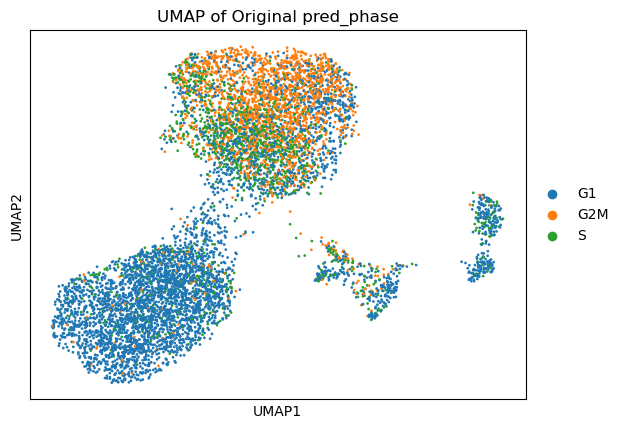

In [9]:
sc.pp.neighbors(adata, n_neighbors=41, use_rep=None)  # Setting use_rep=None uses raw gene expression

sc.pl.umap(adata, color='pred_phase', title='UMAP of Original pred_phase')

In [10]:
adata_copy = adata.copy()


phases = adata_copy.obs['pred_phase'].values
connectivities = adata_copy.obsp['connectivities']

In [11]:
new_phases = phases.copy()
changed_cells = []

for i in range(connectivities.shape[0]):
    neighbors = np.argsort(connectivities[i].toarray().flatten())[-6:-1]
    neighbor_phases = phases[neighbors]
    unique_phases, counts = np.unique(neighbor_phases, return_counts=True)
    most_common_phase = unique_phases[np.argmax(counts)]
    
    if most_common_phase != phases[i]:
        new_phases[i] = most_common_phase
        changed_cells.append(i)

adata_copy.obs['updated_phase'] = new_phases
adata_copy.obs['phase_changed'] = adata_copy.obs['pred_phase'] != adata_copy.obs['updated_phase']

Number of cells reclassified: 2207


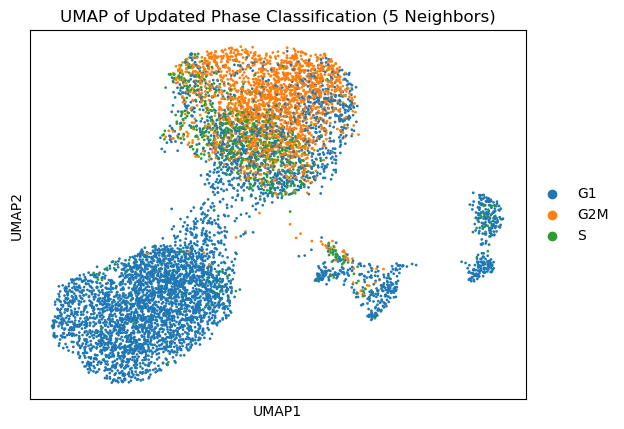

In [12]:
num_changed_cells = len(changed_cells)
print(f"Number of cells reclassified: {num_changed_cells}")
sc.pl.umap(adata_copy, color='updated_phase', title='UMAP of Updated Phase Classification (5 Neighbors)')

In [14]:
def homogenize_phases(adata, phases, connectivities, num_neighbors):
    adata_copy = adata.copy()
    new_phases = phases.copy()
    changed_cells = []
    
    for i in range(connectivities.shape[0]):
        neighbors = np.argsort(connectivities[i].toarray().flatten())[-(num_neighbors + 1):-1]
        neighbor_phases = phases[neighbors]
        unique_phases, counts = np.unique(neighbor_phases, return_counts=True)
        most_common_phase = unique_phases[np.argmax(counts)]
        
        if most_common_phase != phases[i]:
            new_phases[i] = most_common_phase
            changed_cells.append(i)
    
    adata_copy.obs['updated_phase'] = new_phases
    adata_copy.obs['phase_changed'] = adata.obs['pred_phase'] != new_phases
    
    sc.pl.umap(adata_copy, color='updated_phase', title=f'UMAP of Updated Phase Classification ({num_neighbors} Neighbors)')
    return len(changed_cells), adata_copy

In [40]:
cell_cycle_adata = adata[:, adata.var['cell_cycle'] == True]

sc.tl.rank_genes_groups(cell_cycle_adata, groupby='pred_phase', method='t-test')

top_genes_per_phase = {}
for phase in cell_cycle_adata.obs['pred_phase'].unique():
    top_genes = cell_cycle_adata.uns['rank_genes_groups']['names'][phase][:10]
    top_genes_per_phase[phase] = top_genes

top_genes_df = pd.DataFrame(top_genes_per_phase)
print("Top 10 Differentially Expressed Cell Cycle Genes per Phase:")
print(top_genes_df)

cell_cycle_adata = adata[:, adata.var['cell_cycle'] == True]

sc.tl.rank_genes_groups(cell_cycle_adata, groupby='pred_phase', method='t-test')

mark_genes_per_phase = {}

annotations = {
    'G1': ['whitfield_G1/S', 'GO_G1'],
    'S': ['whitfield_S', 'GO_S'],
    'G2M': ['whitfield_G2/M', 'GO_G2']
}

for phase in cell_cycle_adata.obs['pred_phase'].unique():
    ranked_genes = cell_cycle_adata.uns['rank_genes_groups']['names'][phase]
    
    top_genes = []
    for gene in ranked_genes:
        if len(top_genes) >= 10:
            break
        
        if all(cell_cycle_adata.var.loc[gene, annot] for annot in annotations[phase] if annot in cell_cycle_adata.var.columns):
            top_genes.append(gene)

    mark_genes_per_phase[phase] = top_genes

mark_top_genes_df = pd.DataFrame.from_dict(mark_genes_per_phase, orient='index').transpose()
print("Top 10 Differentially Expressed Cell Cycle Genes (Confirmed Markers):")
print(mark_top_genes_df)

/home/sgolts/miniconda3/envs/cells/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Top 10 Differentially Expressed Cell Cycle Genes per Phase:
      G2M      G1       S
0    DKK2  TUBA1A  ZNF763
1    RYBP  SEC24A   ACOX2
2    APIP    EXD2   TDRD9
3  ZBTB41  MAP2K5    APIP
4   DOCK9   MAML3    MGMT
5    MED9    IQCG    DKK2
6    EPN1    PIGF  INPP4B
7    MCM9   BTBD6   GPR68
8    POP4    UPP2    EPN1
9    FZD1  PPP1CC   DOCK9


/home/sgolts/miniconda3/envs/cells/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Top 10 Differentially Expressed Cell Cycle Genes (Confirmed Markers):
      G2M      G1       S
0    DKK2  TUBA1A  ZNF763
1    RYBP  SEC24A   ACOX2
2    APIP    EXD2   TDRD9
3  ZBTB41  MAP2K5    APIP
4   DOCK9   MAML3    MGMT
5    MED9    IQCG    DKK2
6    EPN1    PIGF  INPP4B
7    MCM9   BTBD6   GPR68
8    POP4    UPP2    EPN1
9    FZD1  PPP1CC   DOCK9


In [36]:
def evaluate_scoring(adata, top_genes_df, phase_column='updated_phase'):
    # Extract gene lists from `top_genes_df` for each phase
    g1_genes = top_genes_df['G1'].dropna().tolist()
    s_genes = top_genes_df['S'].dropna().tolist()
    g2m_genes = top_genes_df['G2M'].dropna().tolist()

    sc.tl.score_genes(adata, gene_list=g1_genes, score_name='G1_score')
    sc.tl.score_genes(adata, gene_list=s_genes, score_name='S_score')
    sc.tl.score_genes(adata, gene_list=g2m_genes, score_name='G2M_score')

    phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()

    print("Phase marker scores by phase group:")
    print(phase_scores)
    return phase_scores

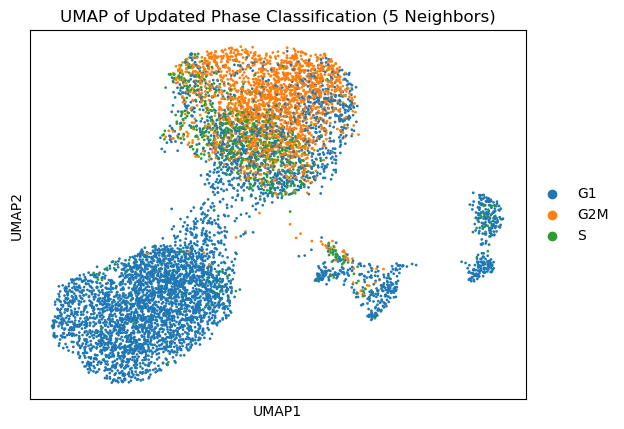

Original Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
            G1_score   S_score  G2M_score
pred_phase                               
G1          0.541669 -0.269308  -0.157772
G2M         0.107226  0.322615   0.714838
S           0.294853  0.213811   0.322197
Updated Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
               G1_score   S_score  G2M_score
updated_phase                               
G1             0.541699 -0.274534  -0.171171
G2M            0.091846  0.371020   0.768447
S              0.242786  0.365770   0.444550


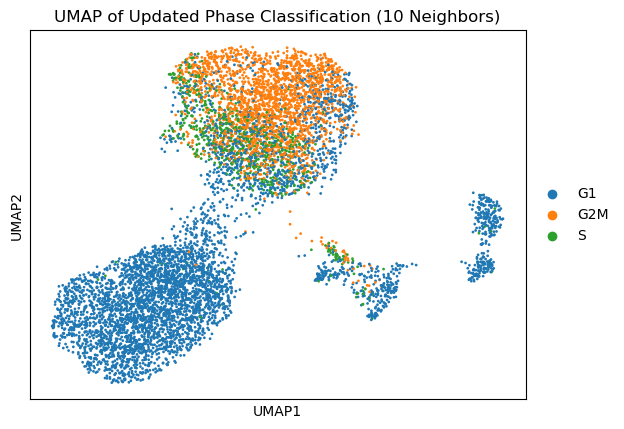

Original Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
            G1_score   S_score  G2M_score
pred_phase                               
G1          0.541669 -0.269308  -0.157772
G2M         0.107226  0.322615   0.714838
S           0.294853  0.213811   0.322197
Updated Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
               G1_score   S_score  G2M_score
updated_phase                               
G1             0.560275 -0.298451  -0.202698
G2M            0.085016  0.376300   0.777525
S              0.211662  0.397299   0.474063


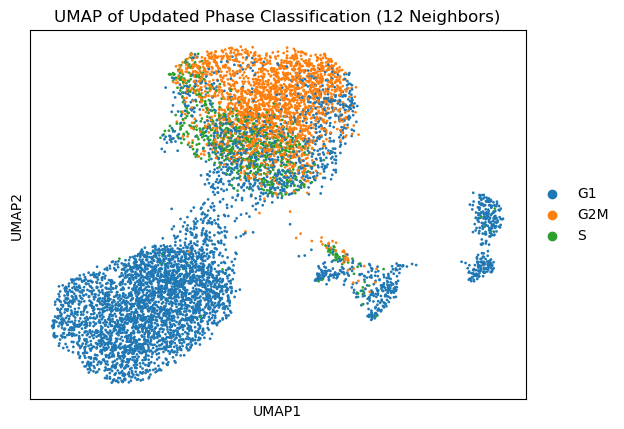

Original Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
            G1_score   S_score  G2M_score
pred_phase                               
G1          0.541669 -0.269308  -0.157772
G2M         0.107226  0.322615   0.714838
S           0.294853  0.213811   0.322197
Updated Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
               G1_score   S_score  G2M_score
updated_phase                               
G1             0.559545 -0.294267  -0.200140
G2M            0.079816  0.375053   0.782549
S              0.214798  0.411754   0.475732


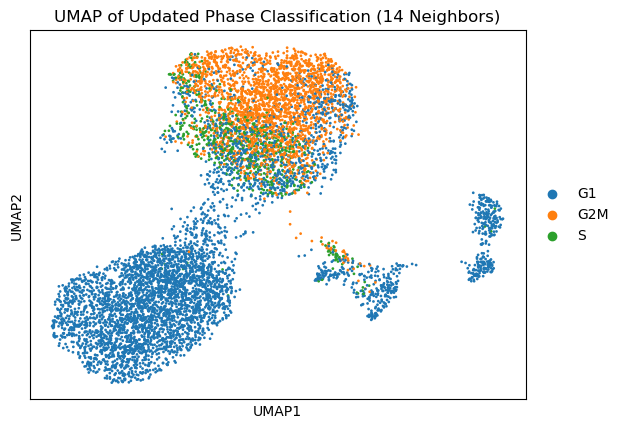

Original Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
            G1_score   S_score  G2M_score
pred_phase                               
G1          0.541669 -0.269308  -0.157772
G2M         0.107226  0.322615   0.714838
S           0.294853  0.213811   0.322197
Updated Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
               G1_score   S_score  G2M_score
updated_phase                               
G1             0.560866 -0.297482  -0.204031
G2M            0.083629  0.373956   0.776677
S              0.212613  0.420157   0.481457


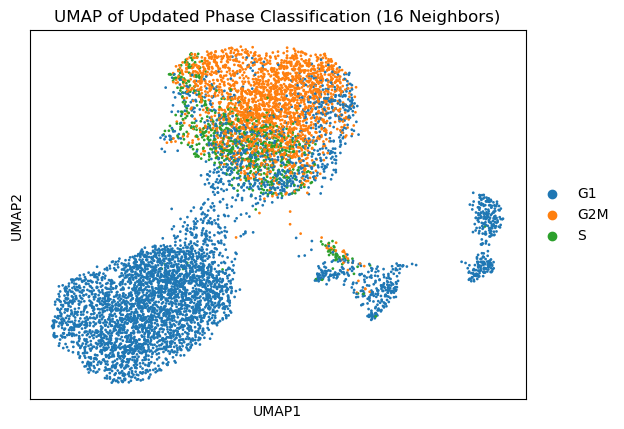

Original Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
            G1_score   S_score  G2M_score
pred_phase                               
G1          0.541669 -0.269308  -0.157772
G2M         0.107226  0.322615   0.714838
S           0.294853  0.213811   0.322197
Updated Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
               G1_score   S_score  G2M_score
updated_phase                               
G1             0.568660 -0.308099  -0.215549
G2M            0.083526  0.377290   0.775119
S              0.196235  0.420117   0.488360


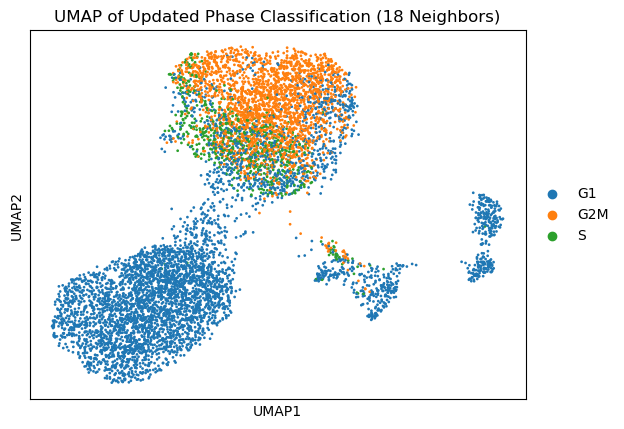

Original Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
            G1_score   S_score  G2M_score
pred_phase                               
G1          0.541669 -0.269308  -0.157772
G2M         0.107226  0.322615   0.714838
S           0.294853  0.213811   0.322197
Updated Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
               G1_score   S_score  G2M_score
updated_phase                               
G1             0.568921 -0.306211  -0.215949
G2M            0.081191  0.375957   0.776721
S              0.198516  0.421165   0.492637


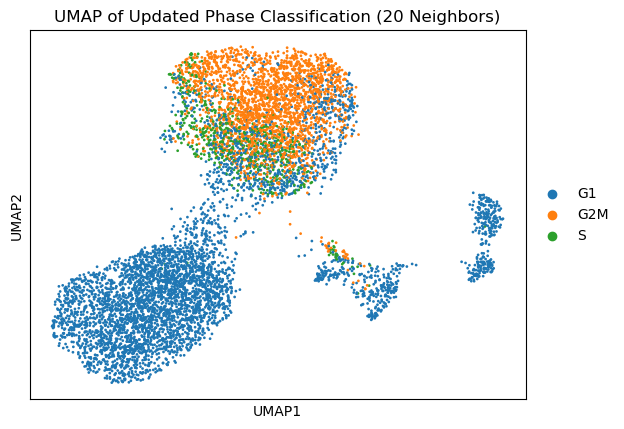

Original Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
            G1_score   S_score  G2M_score
pred_phase                               
G1          0.541669 -0.269308  -0.157772
G2M         0.107226  0.322615   0.714838
S           0.294853  0.213811   0.322197
Updated Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
               G1_score   S_score  G2M_score
updated_phase                               
G1             0.571522 -0.310284  -0.221400
G2M            0.080399  0.375796   0.776631
S              0.202296  0.429646   0.491426


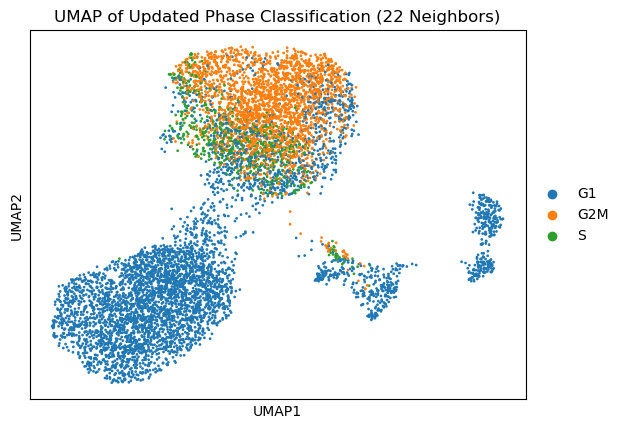

Original Prediction Scoring


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


Phase marker scores by phase group:
            G1_score   S_score  G2M_score
pred_phase                               
G1          0.541669 -0.269308  -0.157772
G2M         0.107226  0.322615   0.714838
S           0.294853  0.213811   0.322197
Updated Prediction Scoring
Phase marker scores by phase group:
               G1_score   S_score  G2M_score
updated_phase                               
G1             0.573875 -0.312982  -0.224871
G2M            0.080013  0.374802   0.776271
S              0.201857  0.429566   0.486621


/tmp/ipykernel_328192/1447132389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_scores = adata.obs.groupby(phase_column)[['G1_score', 'S_score', 'G2M_score']].mean()


In [41]:
neighbor_values=[5, 10, 12, 14, 16, 18, 20, 22]
sweep_results = []

for num_neighbors in neighbor_values:
    num_changed_cells, adata_modified = homogenize_phases(adata, phases, connectivities, num_neighbors)
    sweep_results.append({'num_neighbors': num_neighbors, 'num_changed_cells': num_changed_cells})
    print("Original Prediction Scoring")
    evaluate_scoring(adata_modified, mark_top_genes_df, 'pred_phase')
    print("Updated Prediction Scoring")
    evaluate_scoring(adata_modified, mark_top_genes_df, 'updated_phase')
        
sweep_df = pd.DataFrame(sweep_results)

In [42]:
sweep_results

[{'num_neighbors': 5, 'num_changed_cells': 2207},
 {'num_neighbors': 10, 'num_changed_cells': 2078},
 {'num_neighbors': 12, 'num_changed_cells': 2012},
 {'num_neighbors': 14, 'num_changed_cells': 2014},
 {'num_neighbors': 16, 'num_changed_cells': 2025},
 {'num_neighbors': 18, 'num_changed_cells': 2009},
 {'num_neighbors': 20, 'num_changed_cells': 1990},
 {'num_neighbors': 22, 'num_changed_cells': 1967}]

## Thoughts
- "Manually" look at gene expression
- Look at diff expression analysis between groups, check log fold change to see if actually enriched
- Find a couple cell cycle genes that are expressed at the highest level in the highest level of genes
- Check marker genes, focus on establishing a good set
- Look into cell cycle prediction methods, scvi, scanpy, see if there are things there
- Understand which genes give us the best signal
- Aim for a set of ~25 genes that help us distinguish which cells are in which phase (do they come from a specific annotation set?)
    - Kegg, Whitfield, GO
- Pull controls by random sampling cells that do not have cell type annotation

In [18]:
adata

AnnData object with n_obs × n_vars = 7748 × 14082
    obs: 'n_genes', 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'pred_G1', 'pred_S', 'pred_G2M', 'dpt_pseudotime'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'seurat_S', 'seurat_G2M', 'is_seurat', 'is_kegg', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'is_whitfield', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'is_GO', 'LIU_G2MvsG0G1', 'LIU_G2MvsS', 'LIU_SvsG0G1', 'is_LIU', 'cell_cycle', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_count

In [19]:
gene_list = adata.var[adata.var['cell_cycle'].astype(bool)].index
gene_list

Index(['PEX14', 'NMNAT1', 'TMEM51', 'TTLL10', 'VPS13D', 'RBP7', 'PDIK1L',
       'SERINC2', 'AJAP1', 'SLC25A33',
       ...
       'GEMIN8', 'OPHN1', 'ACOT9', 'FOXP3', 'PHF8', 'PIM2', 'OTUD5', 'ENOX2',
       'MBNL3', 'PFKFB1'],
      dtype='object', length=5291)

In [20]:
adata_count = sc.get.aggregate(adata, 'pred_phase', 'count_nonzero', layer='counts')
count_df = adata_count.to_df(layer='count_nonzero').T
count_df.head()

,G1,G2M,S
ATAD3B,566.0,309.0,172.0
SKI,1658.0,933.0,520.0
PEX14,207.0,121.0,51.0
PLCH2,181.0,210.0,88.0
HES3,184.0,94.0,64.0


In [21]:
count_df.loc[gene_list].sort_values('G1', ascending=False)

,G1,G2M,S
ASB1,4638.0,1875.0,1228.0
ATG12,4638.0,1875.0,1227.0
PSEN2,4638.0,1876.0,1228.0
TUBA1A,4637.0,1876.0,1229.0
TMEM168,4637.0,1876.0,1228.0
...,...,...,...
MGAT4B,1.0,3.0,1.0
USP25,1.0,2.0,3.0
BHLHB9,1.0,4.0,1.0
PFKFB1,1.0,2.0,3.0


In [22]:
adata.obs['pred_phase'].value_counts()

pred_phase
G1     4643
G2M    1876
S      1229
Name: count, dtype: int64

In [23]:
cell_cycle_adata = adata[:, adata.var['cell_cycle'] == True]

sc.tl.rank_genes_groups(cell_cycle_adata, groupby='pred_phase', method='t-test')

top_genes_per_phase = {}
for phase in cell_cycle_adata.obs['pred_phase'].unique():
    top_genes = cell_cycle_adata.uns['rank_genes_groups']['names'][phase][:10]
    top_genes_per_phase[phase] = top_genes

top_genes_df = pd.DataFrame(top_genes_per_phase)
print("Top 10 Differentially Expressed Cell Cycle Genes per Phase:")
print(top_genes_df)

/home/sgolts/miniconda3/envs/cells/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Top 10 Differentially Expressed Cell Cycle Genes per Phase:
      G2M      G1       S
0    DKK2  TUBA1A  ZNF763
1    RYBP  SEC24A   ACOX2
2    APIP    EXD2   TDRD9
3  ZBTB41  MAP2K5    APIP
4   DOCK9   MAML3    MGMT
5    MED9    IQCG    DKK2
6    EPN1    PIGF  INPP4B
7    MCM9   BTBD6   GPR68
8    POP4    UPP2    EPN1
9    FZD1  PPP1CC   DOCK9


/home/sgolts/miniconda3/envs/cells/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Top 10 Differentially Expressed Cell Cycle Genes:
      G2M      G1       S
0    DKK2  TUBA1A  ZNF763
1    RYBP  SEC24A   ACOX2
2    APIP    EXD2   TDRD9
3  ZBTB41  MAP2K5    APIP
4   DOCK9   MAML3    MGMT
5    MED9    IQCG    DKK2
6    EPN1    PIGF  INPP4B
7    MCM9   BTBD6   GPR68
8    POP4    UPP2    EPN1
9    FZD1  PPP1CC   DOCK9
